# Création d'une carte des régions du **Mali** avec **cartograpy**

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent   # car notebook est dans test/
sys.path.insert(0, str(PROJECT_ROOT))

from cartograpy import data, mapper, processing


In [18]:
# télechargement des limites des Regions du Mali

bound=data.GeoBoundaries()
dataMali=bound.adm("mali","adm1")
# Affichage des données
dataMali.head()

,geometry,shapeName,shapeISO,shapeID,shapeGroup,shapeType
0,"POLYGON ((-7.92938 12.68171, -7.93554 12.68821...",Bamako,ML-BKO,92416918B70420899930674,MLI,ADM1
1,"POLYGON ((4.24284 18.00562, 4.23967 18.00372, ...",Gao,ML-7,92416918B98496355207236,MLI,ADM1
2,"POLYGON ((-9.13614 15.49723, -9.32934 15.4968,...",Kayes,ML-1,92416918B67011525583155,MLI,ADM1
3,"POLYGON ((4.24284 18.00562, 4.24172 18.07478, ...",Kidal,ML-8,92416918B67702032852187,MLI,ADM1
4,"POLYGON ((-9.04476 12.42636, -9.02295 12.4194,...",Koulikouro,ML-2,92416918B61022065682725,MLI,ADM1


In [19]:
# Ajout des données de population
popuMali=data.load("data_population_with_density.csv")
popuMali.head()

,Unnamed: 0,shapeName,Population (2022),Area (km²),Density (per km²)
0,0,Bamako,4227569,252,16776.1
1,1,Gao,727516,150000,4.9
2,2,Kayes,1840329,48200,38.2
3,3,Kidal,83192,407000,0.2
4,4,Koulikouro,2255157,47050,47.9


In [20]:
import pandas as pd 

In [22]:
from cartograpy import mapper2

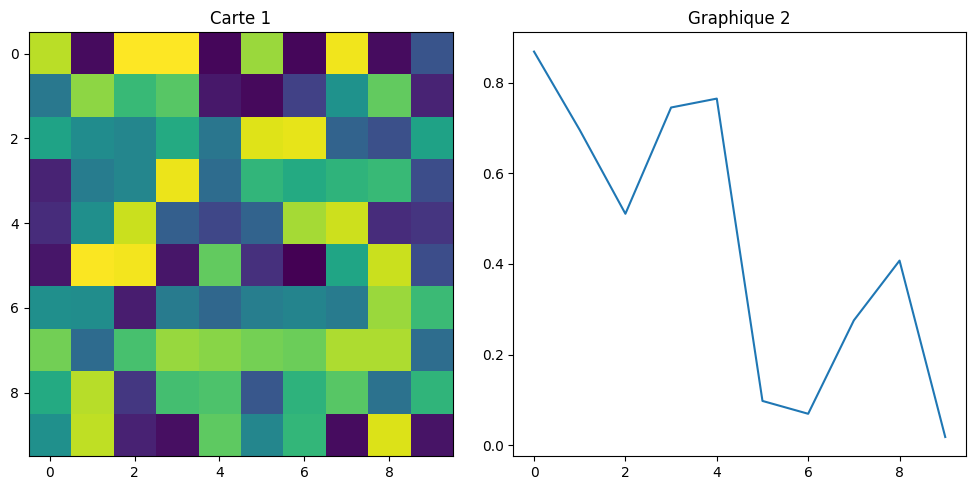

📄 Format de papier: A4 (landscape) - Dimensions: 210 x 297 mm - Figure: 11.7" x 8.3"
⚠️  Attention: Aucun CRS défini. Attribution du CRS par défaut: EPSG:4326
['Polygon']
📊 Centrage intelligent appliqué:
   Format: A4 (landscape)
   Ratio figure: 1.41
   Ratio données: 1.11
   Étendue: [-16.61, 8.61, 8.66, 26.49]
🛑Element de légende ajouté None
✅ Légende personnalisée créée avec 1 éléments


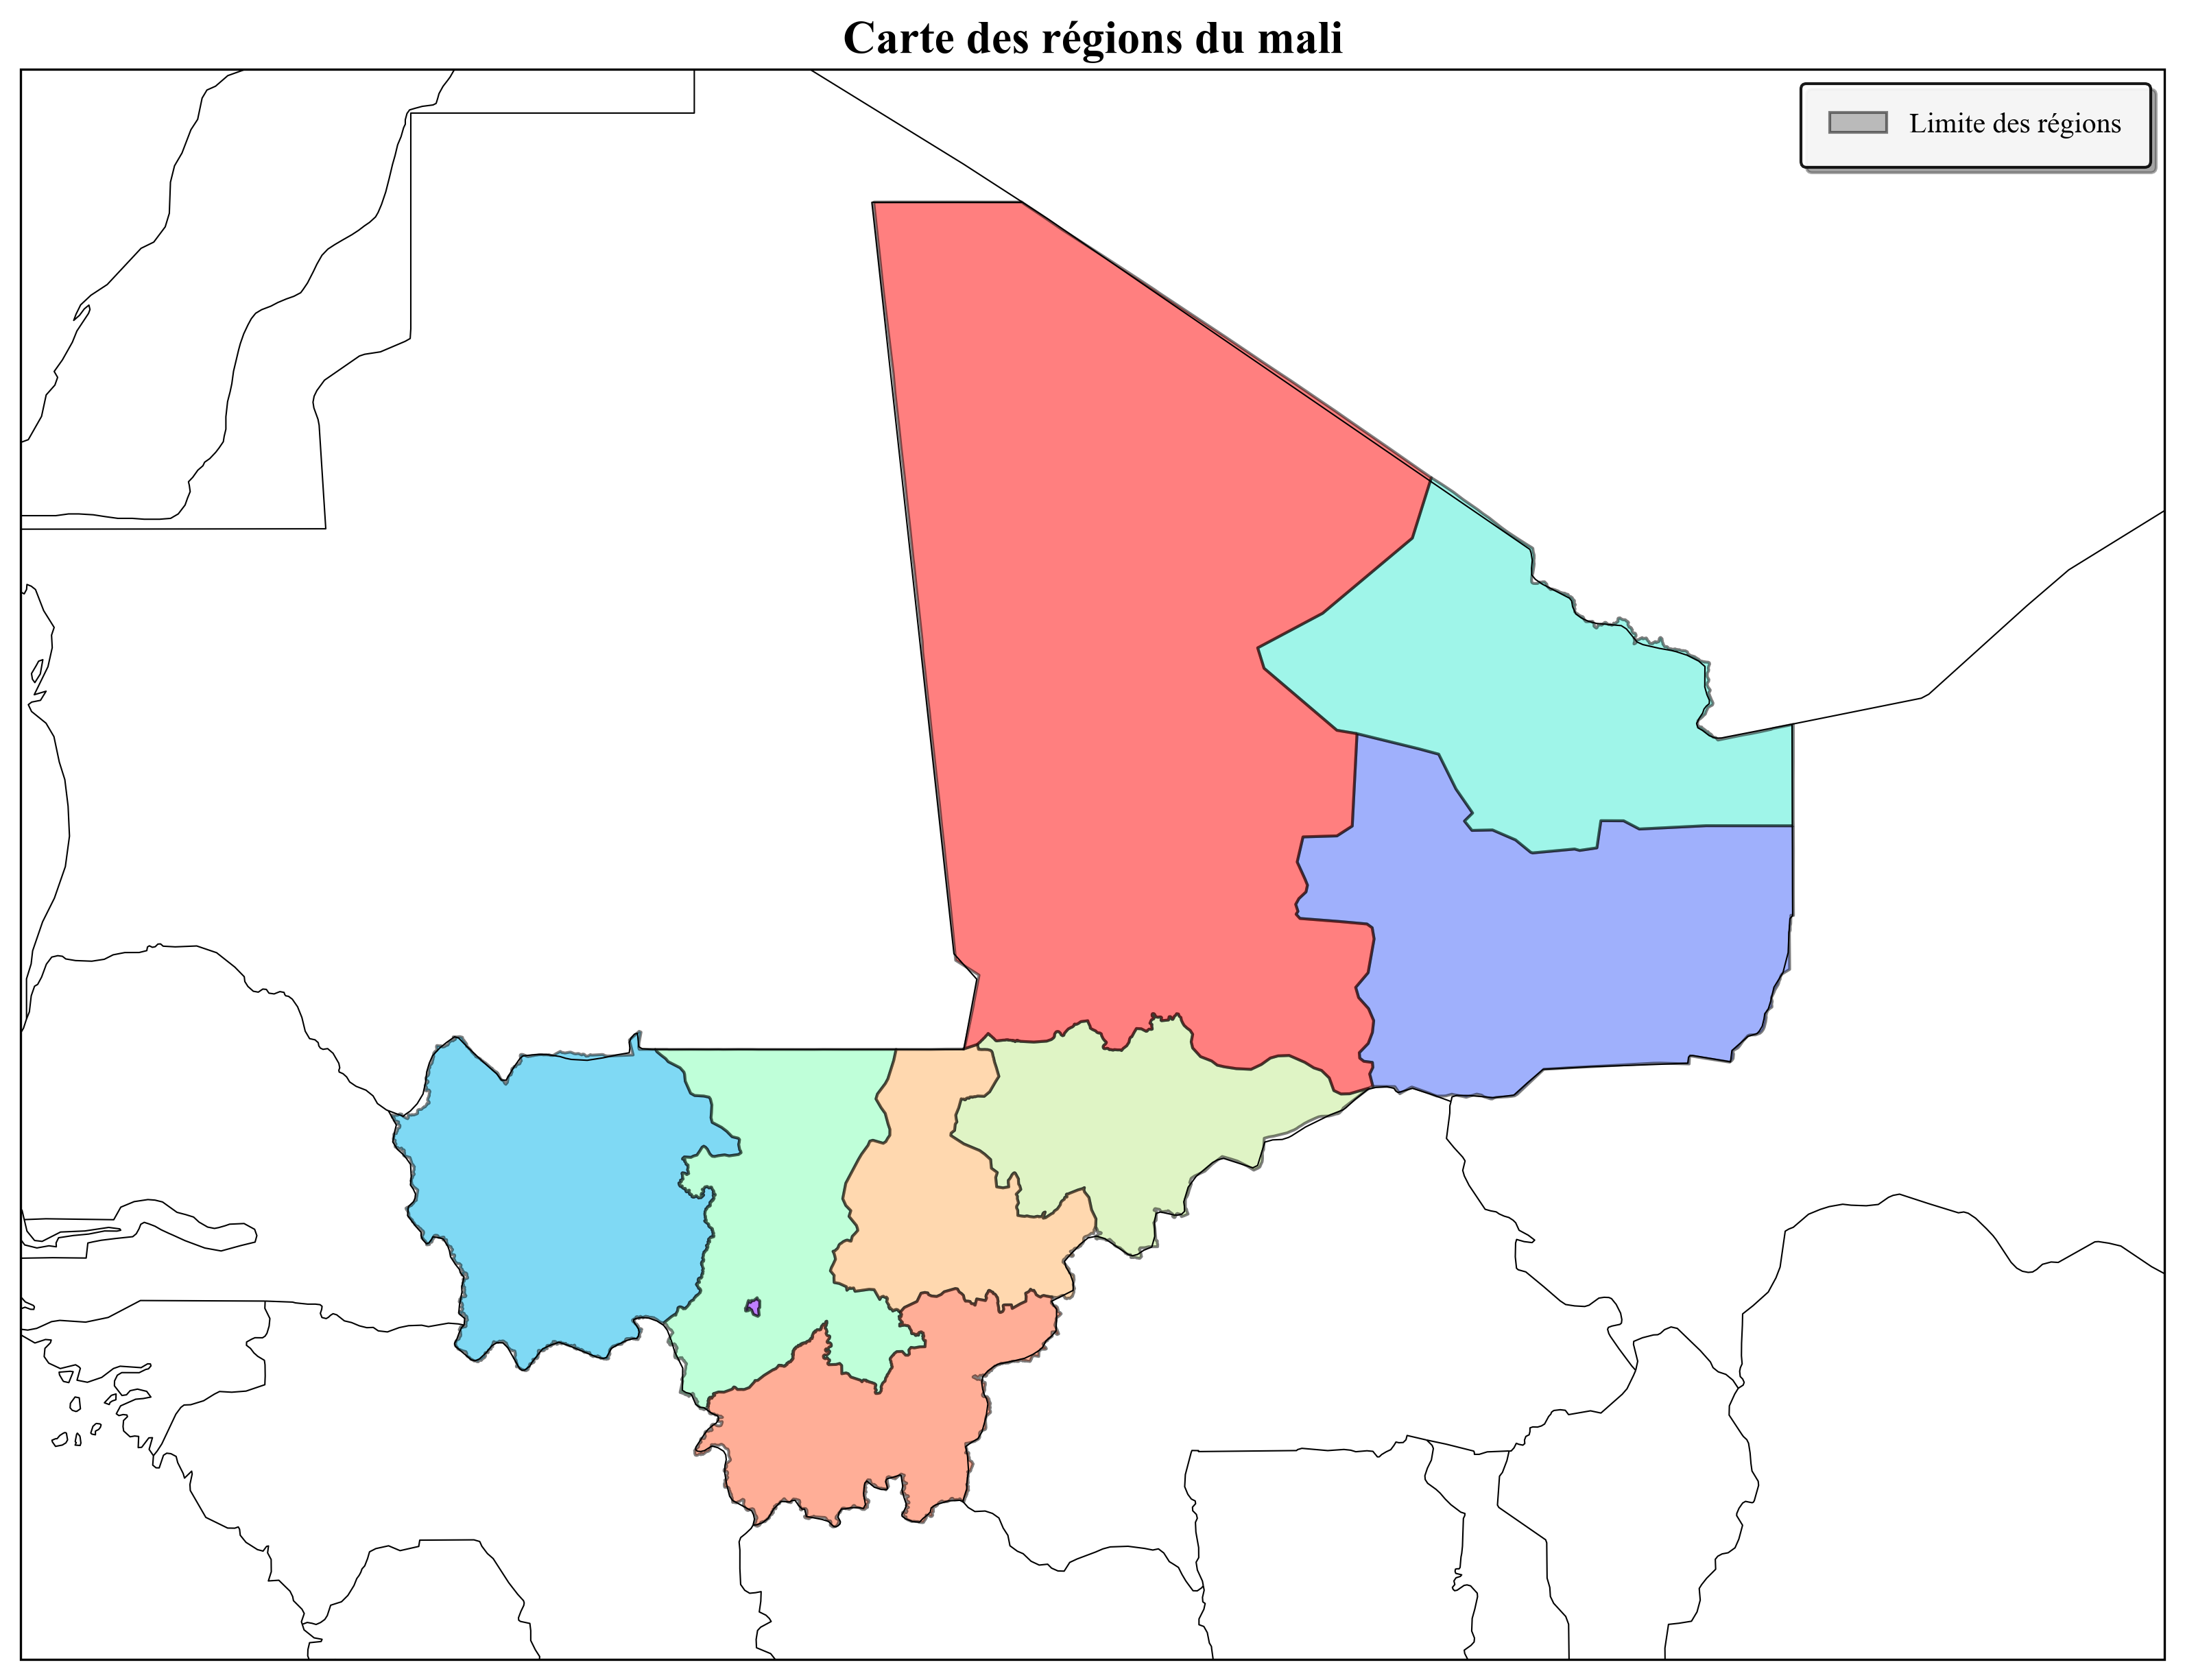

In [ ]:
# Creation de la carte des régions
carteMali=mapper.Map("A4", title="Carte des régions du mali")
carteMali.add_layer(dataMali,label="Limite des régions",cmap="rainbow",column="shapeName")
carteMali.show()
# Ajout d'element a la carte 



In [ ]:
geocode=data.Geocoder()
bbox=geocode.bbox("Yamoussoukro, ci")
bbox_ci = (-8.6, 4.3, -2.5, 10.8)  # Côte d'Ivoire approx
out = download_srtm_dem_no_api_key(bbox, "SRTM30m_CIV.tif", resolution_m=30)
print("OK ->", out)


OK -> SRTM30m_CIV.tif


In [ ]:
import rasterio
import matplotlib.pyplot as plt

tif_path = "SRTM30m_CIV.tif"

with rasterio.open(tif_path) as src:
    arr = src.read(1)           # bande 1
    nodata = src.nodata

# Masquer les NoData pour un rendu propre
if nodata is not None:
    import numpy as np
    arr = np.ma.masked_equal(arr, nodata)

plt.figure(figsize=(10, 6))
plt.imshow(arr)
plt.colorbar(label="Elevation (m)")
plt.title("DEM (GeoTIFF)")
plt.axis("off")
plt.show()

: 